<a href="https://colab.research.google.com/github/BharathRaj24GH/ART-INT/blob/main/AI%5Bff%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# Get uploaded file name
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("✅ Dataset Loaded Successfully!")
print("Shape of dataset:", df.shape)
df.head()

Saving megaGymDataset.csv to megaGymDataset.csv
✅ Dataset Loaded Successfully!
Shape of dataset: (2918, 9)


,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [ ]:
df = df.dropna()

print("After removing null values:")
print("Shape:", df.shape)

After removing null values:
Shape: (501, 9)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (400, 8)
Test shape: (101, 8)


In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE (Train):", X_train.shape)
print("Test data (unchanged):", X_test.shape)

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (Train only):", X_train_sm.shape)
print("Test data (still same):", X_test.shape)

print("\nRow increase:", X_train_sm.shape[0] - X_train.shape[0])
print("Column change:", X_train_sm.shape[1] - X_train.shape[1])

Before SMOTE (Train): (400, 8)
Test data (unchanged): (101, 8)

After SMOTE (Train only): (990, 8)
Test data (still same): (101, 8)

Row increase: 590
Column change: 0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

# Scale
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before PCA:", X_train_scaled.shape)

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("After PCA:", X_train_pca.shape)

print("Column reduction:", X_train_scaled.shape[1] - X_train_pca.shape[1])

Before PCA: (400, 8)
After PCA: (400, 5)
Column reduction: 3


In [ ]:
# Scale SMOTE data
X_train_sm_scaled = scaler.fit_transform(X_train_sm)

# Apply PCA
X_train_sm_pca = pca.fit_transform(X_train_sm_scaled)

# Apply SAME PCA to test data
X_test_sm_pca = pca.transform(X_test_scaled)

print("Original Train:", X_train.shape)
print("After SMOTE:", X_train_sm.shape)
print("After PCA:", X_train_sm_pca.shape)

print("Row increase (SMOTE):", X_train_sm.shape[0] - X_train.shape[0])
print("Column reduction (PCA):", X_train_sm.shape[1] - X_train_sm_pca.shape[1])

Original Train: (400, 8)
After SMOTE: (990, 8)
After PCA: (990, 5)
Row increase (SMOTE): 590
Column reduction (PCA): 3


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def train_evaluate(X_tr, X_te, y_tr, y_te, label):
    results = []

    print(f"\n===== {label} =====\n")

    for name, model in models.items():
        model.fit(X_tr, y_tr)

        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)

        train_acc = accuracy_score(y_tr, y_pred_train)
        test_acc = accuracy_score(y_te, y_pred_test)

        print(f"\nModel: {name}")
        print("Train Accuracy:", train_acc)
        print("Test Accuracy:", test_acc)

        print("\nClass-wise Accuracy:")
        print(classification_report(y_te, y_pred_test))

        results.append([name, label, train_acc, test_acc])

    return results

In [ ]:
results_all = []

results_all += train_evaluate(
    X_train, X_test, y_train, y_test,
    "Without SMOTE & PCA"
)


===== Without SMOTE & PCA =====


Model: Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.7920792079207921

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.39      0.44      0.41        16
           1       0.00      0.00      0.00         1
           2       0.88      0.87      0.87        84

    accuracy                           0.79       101
   macro avg       0.42      0.44      0.43       101
weighted avg       0.79      0.79      0.79       101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model: Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.8316831683168316

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.50      0.31      0.38        16
           1       0.00      0.00      0.00         1
           2       0.87      0.94      0.90        84

    accuracy                           0.83       101
   macro avg       0.46      0.42      0.43       101
weighted avg       0.80      0.83      0.81       101


Model: KNN
Train Accuracy: 0.8625
Test Accuracy: 0.8415841584158416

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.55      0.38      0.44        16
           1       0.00      0.00      0.00         1
           2       0.88      0.94      0.91        84

    accuracy                           0.84       101
   macro avg       0.47      0.44      0.45       101
weighted avg       0.82      0.84      0.83       101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Model: Gradient Boosting
Train Accuracy: 0.9925
Test Accuracy: 0.7821782178217822

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.25      0.12      0.17        16
           1       0.00      0.00      0.00         1
           2       0.84      0.92      0.88        84

    accuracy                           0.78       101
   macro avg       0.36      0.35      0.35       101
weighted avg       0.74      0.78      0.75       101


Model: AdaBoost
Train Accuracy: 0.765
Test Accuracy: 0.7524752475247525

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.28      0.31      0.29        16
           1       0.00      0.00      0.00         1
           2       0.86      0.85      0.85        84

    accuracy                           0.75       101
   macro avg       0.38      0.39      0.38       101
weighted avg       0.76      0.75      0.75       101


Model: SVM
Train Accuracy: 0.825
Test

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Model: Logistic Regression
Train Accuracy: 0.8175
Test Accuracy: 0.8316831683168316

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00         1
           2       0.83      1.00      0.91        84

    accuracy                           0.83       101
   macro avg       0.28      0.33      0.30       101
weighted avg       0.69      0.83      0.76       101



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [ ]:
results_all += train_evaluate(
    X_train_sm, X_test, y_train_sm, y_test,
    "With SMOTE"
)


===== With SMOTE =====


Model: Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.7128712871287128

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.30      0.38      0.33        16
           1       0.17      1.00      0.29         1
           2       0.87      0.77      0.82        84

    accuracy                           0.71       101
   macro avg       0.44      0.72      0.48       101
weighted avg       0.77      0.71      0.74       101


Model: Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.7524752475247525

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.33      0.38      0.35        16
           1       0.25      1.00      0.40         1
           2       0.87      0.82      0.85        84

    accuracy                           0.75       101
   macro avg       0.49      0.73      0.53       101
weighted avg       0.78      0.75      0.76       101


Model: KNN
Train

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
results_all += train_evaluate(
    X_train_pca, X_test_pca, y_train, y_test,
    "With PCA"
)


===== With PCA =====


Model: Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.7524752475247525

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.25      0.19      0.21        16
           1       0.00      0.00      0.00         1
           2       0.85      0.87      0.86        84

    accuracy                           0.75       101
   macro avg       0.37      0.35      0.36       101
weighted avg       0.75      0.75      0.75       101


Model: Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.8118811881188119

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.33      0.12      0.18        16
           1       0.00      0.00      0.00         1
           2       0.84      0.95      0.89        84

    accuracy                           0.81       101
   macro avg       0.39      0.36      0.36       101
weighted avg       0.75      0.81      0.77       101


Model: KNN
Train A

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Model: Gradient Boosting
Train Accuracy: 0.9925
Test Accuracy: 0.8118811881188119

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.50      0.19      0.27        16
           1       0.00      0.00      0.00         1
           2       0.85      0.94      0.89        84

    accuracy                           0.81       101
   macro avg       0.45      0.38      0.39       101
weighted avg       0.79      0.81      0.79       101


Model: AdaBoost
Train Accuracy: 0.7925
Test Accuracy: 0.7128712871287128

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.17      0.19      0.18        16
           1       0.00      0.00      0.00         1
           2       0.83      0.82      0.83        84

    accuracy                           0.71       101
   macro avg       0.33      0.34      0.33       101
weighted avg       0.72      0.71      0.72       101


Model: SVM
Train Accuracy: 0.83
Test

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
results_all += train_evaluate(
    X_train_sm_pca, X_test_sm_pca, y_train_sm, y_test,
    "With SMOTE + PCA"
)


===== With SMOTE + PCA =====


Model: Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.5742574257425742

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.27      0.50      0.35        16
           1       0.00      0.00      0.00         1
           2       0.86      0.60      0.70        84

    accuracy                           0.57       101
   macro avg       0.38      0.37      0.35       101
weighted avg       0.76      0.57      0.64       101


Model: Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.6039603960396039

Class-wise Accuracy:
              precision    recall  f1-score   support

           0       0.32      0.75      0.44        16
           1       0.00      0.00      0.00         1
           2       0.91      0.58      0.71        84

    accuracy                           0.60       101
   macro avg       0.41      0.44      0.38       101
weighted avg       0.80      0.60      0.66       101


Model: KNN

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results_all, columns=[
    "Model", "Technique", "Train Accuracy", "Test Accuracy"
])

print(results_df)

                  Model            Technique  Train Accuracy  Test Accuracy
0         Decision Tree  Without SMOTE & PCA        1.000000       0.792079
1         Random Forest  Without SMOTE & PCA        1.000000       0.831683
2                   KNN  Without SMOTE & PCA        0.862500       0.841584
3     Gradient Boosting  Without SMOTE & PCA        0.992500       0.782178
4              AdaBoost  Without SMOTE & PCA        0.765000       0.752475
5                   SVM  Without SMOTE & PCA        0.825000       0.831683
6   Logistic Regression  Without SMOTE & PCA        0.817500       0.831683
7         Decision Tree           With SMOTE        1.000000       0.712871
8         Random Forest           With SMOTE        1.000000       0.752475
9                   KNN           With SMOTE        0.912121       0.752475
10    Gradient Boosting           With SMOTE        0.977778       0.742574
11             AdaBoost           With SMOTE        0.579798       0.683168
12          

In [ ]:
results_df["Overfitting Gap"] = results_df["Train Accuracy"] - results_df["Test Accuracy"]

print(results_df)

                  Model            Technique  Train Accuracy  Test Accuracy  \
0         Decision Tree  Without SMOTE & PCA        1.000000       0.792079   
1         Random Forest  Without SMOTE & PCA        1.000000       0.831683   
2                   KNN  Without SMOTE & PCA        0.862500       0.841584   
3     Gradient Boosting  Without SMOTE & PCA        0.992500       0.782178   
4              AdaBoost  Without SMOTE & PCA        0.765000       0.752475   
5                   SVM  Without SMOTE & PCA        0.825000       0.831683   
6   Logistic Regression  Without SMOTE & PCA        0.817500       0.831683   
7         Decision Tree           With SMOTE        1.000000       0.712871   
8         Random Forest           With SMOTE        1.000000       0.752475   
9                   KNN           With SMOTE        0.912121       0.752475   
10    Gradient Boosting           With SMOTE        0.977778       0.742574   
11             AdaBoost           With SMOTE        

In [ ]:
best_model = results_df.loc[results_df["Test Accuracy"].idxmax()]

print("🔥 Best Model:")
print(best_model)

🔥 Best Model:
Model                              KNN
Technique          Without SMOTE & PCA
Train Accuracy                  0.8625
Test Accuracy                 0.841584
Overfitting Gap               0.020916
Name: 2, dtype: object


In [ ]:
top5 = results_df.sort_values(by="Test Accuracy", ascending=False).head(5)
print(top5)

                  Model            Technique  Train Accuracy  Test Accuracy  \
2                   KNN  Without SMOTE & PCA          0.8625       0.841584   
1         Random Forest  Without SMOTE & PCA          1.0000       0.831683   
6   Logistic Regression  Without SMOTE & PCA          0.8175       0.831683   
5                   SVM  Without SMOTE & PCA          0.8250       0.831683   
16                  KNN             With PCA          0.8725       0.831683   

    Overfitting Gap  
2          0.020916  
1          0.168317  
6         -0.014183  
5         -0.006683  
16         0.040817  


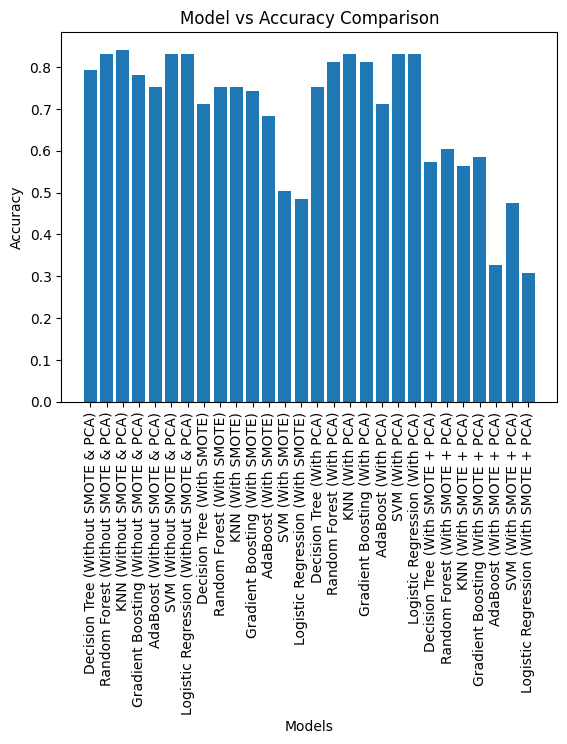

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results_df["Model"] + " (" + results_df["Technique"] + ")",
        results_df["Test Accuracy"])

plt.xticks(rotation=90)
plt.title("Model vs Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

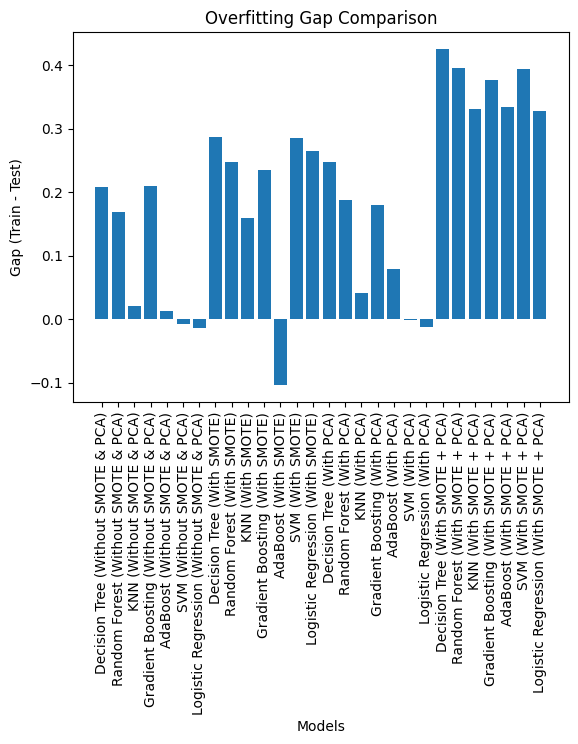

In [ ]:
plt.figure()

plt.bar(results_df["Model"] + " (" + results_df["Technique"] + ")",
        results_df["Overfitting Gap"])

plt.xticks(rotation=90)
plt.title("Overfitting Gap Comparison")
plt.xlabel("Models")
plt.ylabel("Gap (Train - Test)")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best Score:", dt_grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best Score: 0.77


In [ ]:
best_dt = dt_grid.best_estimator_

y_pred = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy after tuning:", accuracy_score(y_test, y_pred))

Test Accuracy after tuning: 0.8415841584158416


In [ ]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=3,
    scoring='accuracy'
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': 5, 'n_estimators': 100}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 🔹 Step 1: Scale data (VERY IMPORTANT)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Step 2: Define parameters
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# 🔹 Step 3: GridSearch
svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=3,
    scoring='accuracy'
)

# 🔹 Step 4: Train
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM Params:", svm_grid.best_params_)

# 🔹 Step 5: Test accuracy
best_svm = svm_grid.best_estimator_

from sklearn.metrics import accuracy_score

y_pred = best_svm.predict(X_test_scaled)

print("Test Accuracy after tuning:", accuracy_score(y_test, y_pred))

Best SVM Params: {'C': 0.1, 'kernel': 'linear'}
Test Accuracy after tuning: 0.8316831683168316


In [ ]:
print("Before tuning:", results_df[results_df["Model"]=="Decision Tree"])

print("After tuning:", accuracy_score(y_test, y_pred))

Before tuning:             Model            Technique  Train Accuracy  Test Accuracy  \
0   Decision Tree  Without SMOTE & PCA             1.0       0.792079   
7   Decision Tree           With SMOTE             1.0       0.712871   
14  Decision Tree             With PCA             1.0       0.752475   
21  Decision Tree     With SMOTE + PCA             1.0       0.574257   

    Overfitting Gap  
0          0.207921  
7          0.287129  
14         0.247525  
21         0.425743  
After tuning: 0.8316831683168316


<Figure size 640x480 with 0 Axes>

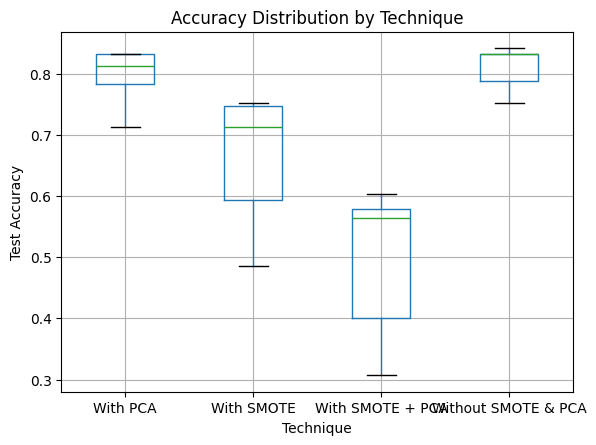

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

results_df.boxplot(column="Test Accuracy", by="Technique")

plt.title("Accuracy Distribution by Technique")
plt.suptitle("")  # removes extra title
plt.xlabel("Technique")
plt.ylabel("Test Accuracy")

plt.show()

<Figure size 640x480 with 0 Axes>

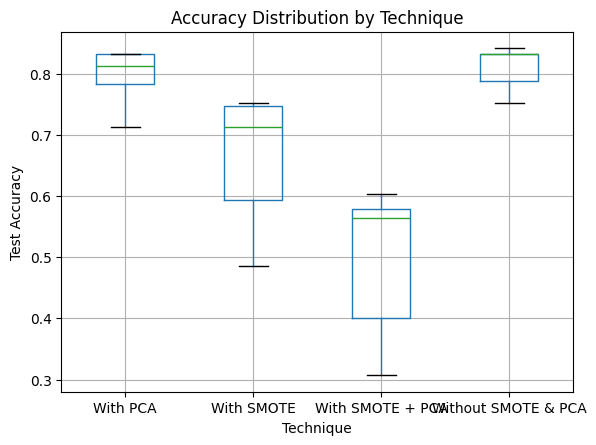

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

results_df.boxplot(column="Test Accuracy", by="Technique")

plt.title("Accuracy Distribution by Technique")
plt.suptitle("")  # removes extra title
plt.xlabel("Technique")
plt.ylabel("Test Accuracy")

plt.show()

In [ ]:
best_row = results_df.loc[results_df["Test Accuracy"].idxmax()]

print(best_row)

Model                              KNN
Technique          Without SMOTE & PCA
Train Accuracy                  0.8625
Test Accuracy                 0.841584
Overfitting Gap               0.020916
Name: 2, dtype: object


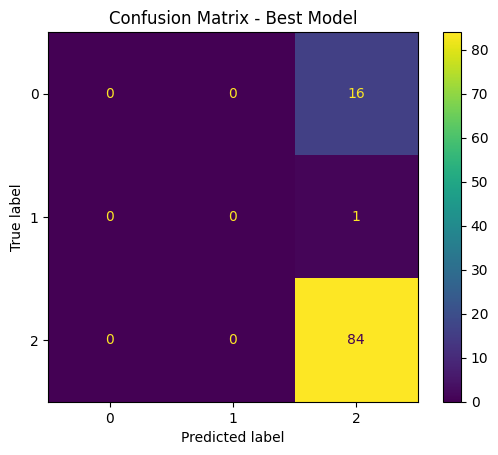

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Best Model")
plt.show()

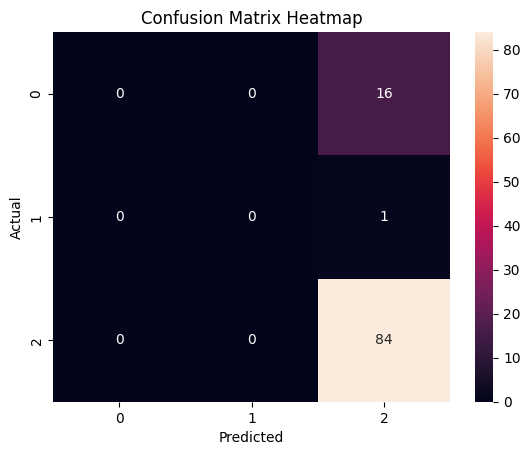

In [ ]:
import seaborn as sns

plt.figure()

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

tuned_results = []

# =========================
# Define Models + Parameters
# =========================
param_grids = {

    "Decision Tree": (
        DecisionTreeClassifier(),
        {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(),
        {
            "n_estimators": [50, 100],
            "max_depth": [5, 10, None]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.01, 0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.5, 1.0]
        }
    ),

    "SVM": (
        SVC(),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
    ),

    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {
            "C": [0.1, 1, 10]
        }
    )
}


# =========================
# Scaling (for SVM, KNN, LR)
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# Run GridSearch for ALL
# =========================
for name, (model, params) in param_grids.items():

    print(f"\n🔍 Tuning {name}...\n")

    # Use scaled data for certain models
    if name in ["SVM", "KNN", "Logistic Regression"]:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    grid = GridSearchCV(
        model,
        params,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_tr, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)

    print("Best Params:", grid.best_params_)
    print("Test Accuracy:", acc)

    tuned_results.append([
        name,
        grid.best_params_,
        acc
    ])


# =========================
# Final Results Table
# =========================
tuned_df = pd.DataFrame(tuned_results, columns=[
    "Model", "Best Parameters", "Test Accuracy"
])

print("\n🔥 FINAL TUNED RESULTS:")
print(tuned_df.sort_values(by="Test Accuracy", ascending=False))


🔍 Tuning Decision Tree...

Best Params: {'max_depth': 3, 'min_samples_split': 2}
Test Accuracy: 0.8316831683168316

🔍 Tuning Random Forest...

Best Params: {'max_depth': 10, 'n_estimators': 100}
Test Accuracy: 0.8316831683168316

🔍 Tuning KNN...

Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
Test Accuracy: 0.8415841584158416

🔍 Tuning Gradient Boosting...

Best Params: {'learning_rate': 0.01, 'n_estimators': 50}
Test Accuracy: 0.8316831683168316

🔍 Tuning AdaBoost...

Best Params: {'learning_rate': 0.5, 'n_estimators': 50}
Test Accuracy: 0.7821782178217822

🔍 Tuning SVM...

Best Params: {'C': 0.1, 'kernel': 'linear'}
Test Accuracy: 0.8316831683168316

🔍 Tuning Logistic Regression...

Best Params: {'C': 0.1}
Test Accuracy: 0.8316831683168316

🔥 FINAL TUNED RESULTS:
                 Model                              Best Parameters  \
2                  KNN     {'n_neighbors': 7, 'weights': 'uniform'}   
0        Decision Tree     {'max_depth': 3, 'min_samples_split': 2}   
1  

In [ ]:
print("Before tuning:")
print(results_df.sort_values(by="Test Accuracy", ascending=False).head())

print("\nAfter tuning:")
print(tuned_df.sort_values(by="Test Accuracy", ascending=False))

Before tuning:
                  Model            Technique  Train Accuracy  Test Accuracy  \
2                   KNN  Without SMOTE & PCA          0.8625       0.841584   
1         Random Forest  Without SMOTE & PCA          1.0000       0.831683   
6   Logistic Regression  Without SMOTE & PCA          0.8175       0.831683   
5                   SVM  Without SMOTE & PCA          0.8250       0.831683   
16                  KNN             With PCA          0.8725       0.831683   

    Overfitting Gap  
2          0.020916  
1          0.168317  
6         -0.014183  
5         -0.006683  
16         0.040817  

After tuning:
                 Model                              Best Parameters  \
2                  KNN     {'n_neighbors': 7, 'weights': 'uniform'}   
0        Decision Tree     {'max_depth': 3, 'min_samples_split': 2}   
1        Random Forest       {'max_depth': 10, 'n_estimators': 100}   
3    Gradient Boosting  {'learning_rate': 0.01, 'n_estimators': 50}   
5       

In [ ]:
print(df['Level'].value_counts())

Level
2    414
0     80
1      7
Name: count, dtype: int64


In [ ]:
print(df['Level'].value_counts(normalize=True) * 100)

Level
2    82.634731
0    15.968064
1     1.397206
Name: proportion, dtype: float64


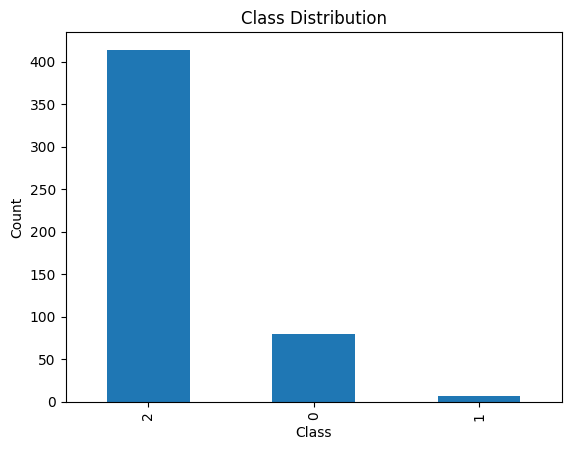

In [ ]:
import matplotlib.pyplot as plt

df['Level'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()